In [65]:
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors 

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgba

import pandas as pd 
import seaborn as sns 
pd.options.mode.chained_assignment = None
import numpy as np 
import json
import sys
import glob 
import scipy.stats

from config import home_path, llm_review_path, supp_table_path

sys.path.insert(1, home_path) 
from common_functions import p_val_to_stars, entropy, mean_confidence_interval, format_p, read_fasta, sort_dict_by_value, get_pfam_info


In [66]:
def augment_masked_df_with_site_entropy(df, limit_normal_aas = True, return_entropy = True):
    regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']
    df["name"] = df["ref_aa"] + df["aa_pos"].astype(str) + df["token_str"]
    df = df.loc[df["token_str"].isin(regular_aas)]
    variant_to_s1 = {}
    variant_to_adj_prob = {}
    variant_to_site_entropy = {}
    for pos, sub_df in df.groupby("aa_pos"):
        v_to_adj_score = {}
        valid_prob_total = np.sum(sub_df["score"])
        for index, row in sub_df.iterrows():
            v_to_adj_score[row["name"]] = row["score"] / valid_prob_total
        
        sub_df["adj_score"] = sub_df["name"].apply(lambda x : v_to_adj_score[x])
        
        wt_val = sub_df.loc[sub_df["ref_aa"] == sub_df["token_str"]]
        assert len(wt_val) == 1
        wt_score = wt_val.iloc[0]["adj_score"]
        
        adj_prob_list = []
        for index, row in sub_df.iterrows():
            variant_to_s1[row["name"]] = np.log(row["adj_score"]) - np.log(wt_score)
            variant_to_adj_prob[row["name"]] = row["adj_score"] / valid_prob_total
            adj_prob_list.append(row["adj_score"] / valid_prob_total)
        ent_val = entropy(adj_prob_list)
        
        for name in sub_df["name"].values: variant_to_site_entropy[name] = ent_val

    if return_entropy:
        df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
            
    df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
    df["adj_score"] = df["name"].apply(lambda x : variant_to_adj_prob[x])
    
    df = df.set_index("name")
    return df



In [67]:
summary_res_path = "./summary_results/"
models = ["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B", "protbert"]
model_to_display_name = {
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" : "ESM-2 (35M)",
    "esm_2_150M" : "ESM-2 (150M)",
    "esm_2_650M" : "ESM-2 (650M)",
    "esm_2" : "ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)",
    "protbert" : "ProtBERT (420M)"
}

human_data = pd.read_csv(llm_review_path + "data/uniprotkb_taxonomy_id_9606_AND_reviewed_2023_10_18.tsv", delimiter = "\t")

In [68]:
model_to_average_site_entropy = {m : {} for m in models}
model_to_correct_aa_by_pos = {m : {} for m in models}

pos_limit = 2000

for m in models:
    with open(summary_res_path + m + "_summary_results.json", "r") as f:
        data = json.load(f)
    f.close()
    
    
    ent_compiled_res = {}
    accuracy_compiled_res = {}
    
    ent_data = data["entropy"]
    accuracy_data = data["correct_aa"]
    
    for position, pos_data in ent_data.items():
        position = int(position)
        if position > pos_limit:
            continue
        mean_val = np.mean(list(pos_data.values()))
        ent_compiled_res[position] = mean_val
        
    model_to_average_site_entropy[m] = ent_compiled_res
    
    
    for position, pos_data in accuracy_data.items():
        position = int(position)
        if position > pos_limit:
            continue    
        total_accuracy = np.sum(list(pos_data.values())) / len(pos_data)
        accuracy_compiled_res[position] = total_accuracy
        
    model_to_correct_aa_by_pos[m] = accuracy_compiled_res
        

In [69]:
model_to_average_site_entropy_3000 = {m : {} for m in models}
model_to_correct_aa_by_pos_3000 = {m : {} for m in models}

pos_limit = 3000

for m in models:
    with open(summary_res_path + m + "_summary_results_3000.json", "r") as f:
        data = json.load(f)
    f.close()
    
    
    ent_compiled_res = {}
    accuracy_compiled_res = {}
    
    ent_data = data["entropy"]
    accuracy_data = data["correct_aa"]
    
    for position, pos_data in ent_data.items():
        position = int(position)
        if position > pos_limit:
            continue
        mean_val = np.mean(list(pos_data.values()))
        ent_compiled_res[position] = mean_val
        
    model_to_average_site_entropy_3000[m] = ent_compiled_res
    
    
    for position, pos_data in accuracy_data.items():
        position = int(position)
        if position > pos_limit:
            continue    
        total_accuracy = np.sum(list(pos_data.values())) / len(pos_data)
        accuracy_compiled_res[position] = total_accuracy
        
    model_to_correct_aa_by_pos_3000[m] = accuracy_compiled_res
        

In [70]:
model_to_average_site_entropy_control = {m : {} for m in models}
model_to_correct_aa_by_pos_control = {m : {} for m in models}
summary_res_path_control = "./summary_results_control_short_sequences/"

for m in models:
    with open(summary_res_path_control + m + "_summary_results.json", "r") as f:
        data = json.load(f)
    f.close()
    
    
    ent_compiled_res = {}
    accuracy_compiled_res = {}
    
    ent_data = data["entropy"]
    accuracy_data = data["correct_aa"]
    
    for position, pos_data in ent_data.items():
        position = int(position)
        mean_val = np.mean(list(pos_data.values()))
        ent_compiled_res[position] = mean_val
        
    model_to_average_site_entropy_control[m] = ent_compiled_res
    
    
    for position, pos_data in accuracy_data.items():
        position = int(position)  
        total_accuracy = np.sum(list(pos_data.values())) / len(pos_data)
        accuracy_compiled_res[position] = total_accuracy
        
    model_to_correct_aa_by_pos_control[m] = accuracy_compiled_res
        

In [71]:
regular_aas = ['P','S','L','A','V','G','T','E','R','Q','D','F','I','H','Y','N','K','C','W','M']
def augment_clinvar_masked_df_with_site_entropy(df, limit_normal_aas = True, return_entropy = True):
    df["name"] = df["ref_aa"] + df["aa_pos"].astype(str) + df["token_str"]
    df = df.loc[df["token_str"].isin(regular_aas)]
    variant_to_s1 = {}
    variant_to_adj_prob = {}
    variant_to_site_entropy = {}
    for pos, sub_df in df.groupby("variant_name"):
        v_to_adj_score = {}
        valid_prob_total = np.sum(sub_df["score"])
        for index, row in sub_df.iterrows():
            v_to_adj_score[row["name"]] = row["score"] / valid_prob_total
        
        sub_df["adj_score"] = sub_df["name"].apply(lambda x : v_to_adj_score[x])
        
        wt_val = sub_df.loc[sub_df["ref_aa"] == sub_df["token_str"]]
        assert len(wt_val) == 1
        wt_score = wt_val.iloc[0]["adj_score"]
        
        adj_prob_list = []
        for index, row in sub_df.iterrows():
            variant_to_s1[row["name"]] = np.log(row["adj_score"]) - np.log(wt_score)
            variant_to_adj_prob[row["name"]] = row["adj_score"] / valid_prob_total
            adj_prob_list.append(row["adj_score"] / valid_prob_total)
        ent_val = entropy(adj_prob_list)
        
        for name in sub_df["name"].values: variant_to_site_entropy[name] = ent_val

    if return_entropy:
        df["site_entropy"] = df["name"].apply(lambda x : variant_to_site_entropy[x])
            
    df["s1"] = df["name"].apply(lambda x : variant_to_s1[x])
    df["adj_score"] = df["name"].apply(lambda x : variant_to_adj_prob[x])
    
    df = df.set_index("name")
    return df



In [72]:
model_to_key = {
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" : "ESM-2 (35M)",
    "esm_2_150M" : "ESM-2 (150M)",
    "esm_2_650M" : "ESM-2 (650M)",
    "esm_2" : "ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)",
}



In [73]:
model_to_plp_scores = {}

for model in model_to_key.keys():
    clinvar_results = pd.read_csv("./clinvar_results_rotary/" + model + "_selected_clinvar_long_with_VUS.csv", index_col = 0)
    if model == "esm_2_15B":
        #could not fit on GPU, did these on CPU
        additional_variants = pd.read_csv(f"./clinvar_results_rotary/{model}_selected_clinvar_long_MISSING_FROM_GPU.csv")
        clinvar_results = pd.concat([clinvar_results, additional_variants])
    
    clinvar_results = augment_clinvar_masked_df_with_site_entropy(clinvar_results)
    clinvar_results["needed_variant"] = clinvar_results["variant_name"].apply(lambda x : x.split("_")[-1])
    clinvar_results_rotary = clinvar_results.loc[clinvar_results.index == clinvar_results["needed_variant"]]

    clinvar_variants_df = pd.read_csv(llm_review_path + "figure_panels/submission/table_csvs/clinvar_misclassification_all_models_all_variants.csv")
    clinvar_variants_df = clinvar_variants_df.loc[clinvar_variants_df["model"] == model_to_key[model]]
    long_clinvar_variants_df = clinvar_variants_df.loc[clinvar_variants_df["full_name"].isin(clinvar_results_rotary["variant_name"].values)]
    short_clinvar_variants_df = clinvar_variants_df.loc[~clinvar_variants_df["full_name"].isin(clinvar_results_rotary["variant_name"].values)]

    plp_variants = set(clinvar_variants_df.loc[clinvar_variants_df["clinvar_annotation"] == "PLP"]["full_name"].values)
    short_plp = short_clinvar_variants_df.loc[short_clinvar_variants_df["clinvar_annotation"] == "PLP"]

    long_plp_rotary = clinvar_results_rotary.loc[clinvar_results_rotary["variant_name"].isin(plp_variants)]
    long_plp_tile = long_clinvar_variants_df.loc[long_clinvar_variants_df["clinvar_annotation"] == "PLP"]

    x1 = short_plp["score"].values
    x2 = long_plp_rotary["s1"].values
    x3 = long_plp_tile["score"].values

    
    model_to_plp_scores[model] = {
        "short_proteins" : x1,
        "long_plp_rotary" : x2,
        "long_plp_tile" : x3
    }

In [74]:
model_to_blb_scores = {}

for model in model_to_key.keys():
    clinvar_results = pd.read_csv("./clinvar_results_rotary/" + model + "_selected_clinvar_long_with_VUS.csv", index_col = 0)
    
    if model == "esm_2_15B":
        #could not fit on GPU, did these on CPU
        additional_variants = pd.read_csv(f"./clinvar_results_rotary/{model}_selected_clinvar_long_MISSING_FROM_GPU.csv")
        clinvar_results = pd.concat([clinvar_results, additional_variants])
    
    
    clinvar_results = augment_clinvar_masked_df_with_site_entropy(clinvar_results)
    clinvar_results["needed_variant"] = clinvar_results["variant_name"].apply(lambda x : x.split("_")[-1])
    clinvar_results_rotary = clinvar_results.loc[clinvar_results.index == clinvar_results["needed_variant"]]

    clinvar_variants_df = pd.read_csv(llm_review_path + "figure_panels/submission/table_csvs/clinvar_misclassification_all_models_all_variants.csv")
    clinvar_variants_df = clinvar_variants_df.loc[clinvar_variants_df["model"] == model_to_key[model]]
    long_clinvar_variants_df = clinvar_variants_df.loc[clinvar_variants_df["full_name"].isin(clinvar_results_rotary["variant_name"].values)]
    short_clinvar_variants_df = clinvar_variants_df.loc[~clinvar_variants_df["full_name"].isin(clinvar_results_rotary["variant_name"].values)]

    blb_variants = set(clinvar_variants_df.loc[clinvar_variants_df["clinvar_annotation"] == "BLB"]["full_name"].values)
    short_blb = short_clinvar_variants_df.loc[short_clinvar_variants_df["clinvar_annotation"] == "BLB"]

    long_blb_rotary = clinvar_results_rotary.loc[clinvar_results_rotary["variant_name"].isin(blb_variants)]
    long_blb_tile = long_clinvar_variants_df.loc[long_clinvar_variants_df["clinvar_annotation"] == "BLB"]

    x1 = short_blb["score"].values
    x2 = long_blb_rotary["s1"].values
    x3 = long_blb_tile["score"].values

    
    model_to_blb_scores[model] = {
        "short_proteins" : x1,
        "long_blb_rotary" : x2,
        "long_blb_tile" : x3
    }

In [75]:
model_to_vus_scores = {}

# missing 5 variant scores from 15B model done on the cpu for space problems, added in this function 

esm_2_genes = set()

for model in model_to_key.keys():
    
    clinvar_results = pd.read_csv("./clinvar_results_rotary/" + model + "_selected_clinvar_long_with_VUS.csv", index_col = 0)
    
    if model == "esm_2_15B":
        #could not fit on GPU, did these on CPU
        additional_variants = pd.read_csv(f"./clinvar_results_rotary/{model}_selected_clinvar_long_MISSING_FROM_GPU.csv")
        clinvar_results = pd.concat([clinvar_results, additional_variants])
    
    
    clinvar_results = augment_clinvar_masked_df_with_site_entropy(clinvar_results)
    clinvar_results["needed_variant"] = clinvar_results["variant_name"].apply(lambda x : x.split("_")[-1])
    clinvar_results_rotary = clinvar_results.loc[clinvar_results.index == clinvar_results["needed_variant"]]

    clinvar_variants_df = pd.read_csv(llm_review_path + "figure_panels/submission/table_csvs/clinvar_misclassification_all_models_all_variants.csv")
    clinvar_variants_df = clinvar_variants_df.loc[clinvar_variants_df["model"] == model_to_key[model]]
    long_clinvar_variants_df = clinvar_variants_df.loc[clinvar_variants_df["full_name"].isin(clinvar_results_rotary["variant_name"].values)]
    short_clinvar_variants_df = clinvar_variants_df.loc[~clinvar_variants_df["full_name"].isin(clinvar_results_rotary["variant_name"].values)]

    vus_variants = set(clinvar_variants_df.loc[clinvar_variants_df["clinvar_annotation"] == "VUS"]["full_name"].values)
    short_vus = short_clinvar_variants_df.loc[short_clinvar_variants_df["clinvar_annotation"] == "VUS"]

    long_vus_rotary = clinvar_results_rotary.loc[clinvar_results_rotary["variant_name"].isin(vus_variants)]
    long_vus_tile = long_clinvar_variants_df.loc[long_clinvar_variants_df["clinvar_annotation"] == "VUS"]
    
    model_to_vus_scores[model] = {
        "short_proteins" : short_vus["score"].values,
        "short_proteins_vus_names" : short_vus["full_name"].values,
        "long_vus_rotary_names" : long_vus_rotary["variant_name"].values,
        "long_vus_rotary" : long_vus_rotary["s1"].values,
        "long_vus_tile_names" : long_vus_tile["full_name"].values,
        "long_vus_tile" : long_vus_tile["score"].values
    }

/tmp/ipykernel_2918821/3205278442.py:47: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([


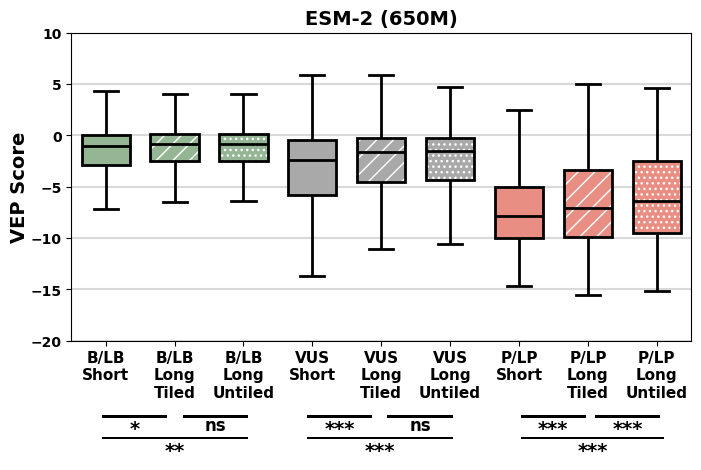

In [76]:
fig, ax = plt.subplots(figsize = (8,4))

chosen_model = "esm_2_650M"

# model_blb = model_to_blb_scores[chosen_model]
model_to_blb_scores.keys()

data = [
    model_to_blb_scores[chosen_model]["short_proteins"],
    model_to_blb_scores[chosen_model]["long_blb_tile"],
    model_to_blb_scores[chosen_model]["long_blb_rotary"],
#     [],
    model_to_vus_scores[chosen_model]["short_proteins"],
    model_to_vus_scores[chosen_model]["long_vus_tile"],
    model_to_vus_scores[chosen_model]["long_vus_rotary"],
#     [],
    model_to_plp_scores[chosen_model]["short_proteins"],
    model_to_plp_scores[chosen_model]["long_plp_tile"],
    model_to_plp_scores[chosen_model]["long_plp_rotary"],    
]

sns.boxplot(
    data, 
    showfliers = False,
    palette = {
        0 : "darkseagreen",
        1: "darkseagreen",
        2 : "darkseagreen",
        3 : "darkgray",
        4: "darkgray",
        5 : "darkgray",
        6 : "salmon",
        7: "salmon",
        8 : "salmon",
    },
    boxprops = {"edgecolor" : "black", "linewidth": 2},
    medianprops = {"color" : "black", "linewidth": 2},
    whiskerprops = {"color" : "black", "linewidth": 2},
    capprops = {"color" : "black", "linewidth": 2}, 
    width = 0.7
)

ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")

ax.set_ylabel(r"VEP Score", fontsize = 14, fontweight = "bold", labelpad =1)
ax.set_xticklabels([
        "B/LB\nShort",
        "B/LB\nLong\nTiled",
        "B/LB\nLong\nUntiled",
        "VUS\nShort",
        "VUS\nLong\nTiled",
        "VUS\nLong\nUntiled",
        "P/LP\nShort",
        "P/LP\nLong\nTiled",
        "P/LP\nLong\nUntiled",
    ],
    fontsize = 11,
    fontweight = "bold"
)

hatch_list = ["", "//", "..."] * 3
c_list = ["white", "white", "white"] * 3
patches = ax.patches
for i, (patch, hatch) in enumerate(zip(patches, hatch_list)):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba(c_list[i])

ax.set_title(model_to_display_name[chosen_model], fontsize = 14, fontweight = "bold")

list_positions_a = [0, 1, 0, 3, 4, 3, 6, 7, 6]
list_positions_b = [1, 2, 2, 4, 5, 5, 7, 8, 8]
lengths = [0.105, 0.105, 0.235,0.105, 0.105, 0.235,0.105, 0.105, 0.231]
start_positions = [0.05, 0.18, 0.05, 0.38, 0.51, 0.38, 0.725, 0.845, 0.725]
y_positions = [-0.25, -0.25, -0.32, -0.25, -0.25, -0.32, -0.25, -0.25, -0.32]

for index, start_pos in enumerate(start_positions):
    rect_length = lengths[index]
    rect_y_pos = y_positions[index]
    x_end_pos = start_pos + rect_length
    rect = mpatches.Rectangle((start_pos, rect_y_pos), rect_length, 0.0075, clip_on = False, facecolor = "black", transform=ax.transAxes)
    ax.add_patch(rect)
    
    st, p = scipy.stats.mannwhitneyu(data[list_positions_a[index]], data[list_positions_b[index]], alternative = "less")
    stars = p_val_to_stars(p)
    text_pos = start_pos  + ((x_end_pos - start_pos ) / 2)
    fs = 12 if stars == "ns" else 14
    y_offset = 0.04 if stars == "ns" else 0.055
    ax.text(text_pos, rect_y_pos - y_offset, stars, fontsize = fs, fontweight = "bold", transform = ax.transAxes, horizontalalignment = "center")
    
for i in ax.get_yticks():
    ax.axhline(y = i, zorder = 1, color = "black", alpha = 0.15)

/tmp/ipykernel_2918821/3110425365.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([
/tmp/ipykernel_2918821/3110425365.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([
/tmp/ipykernel_2918821/3110425365.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([
/tmp/ipykernel_2918821/3110425365.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([
/tmp/ipykernel_2918821/3110425365.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([


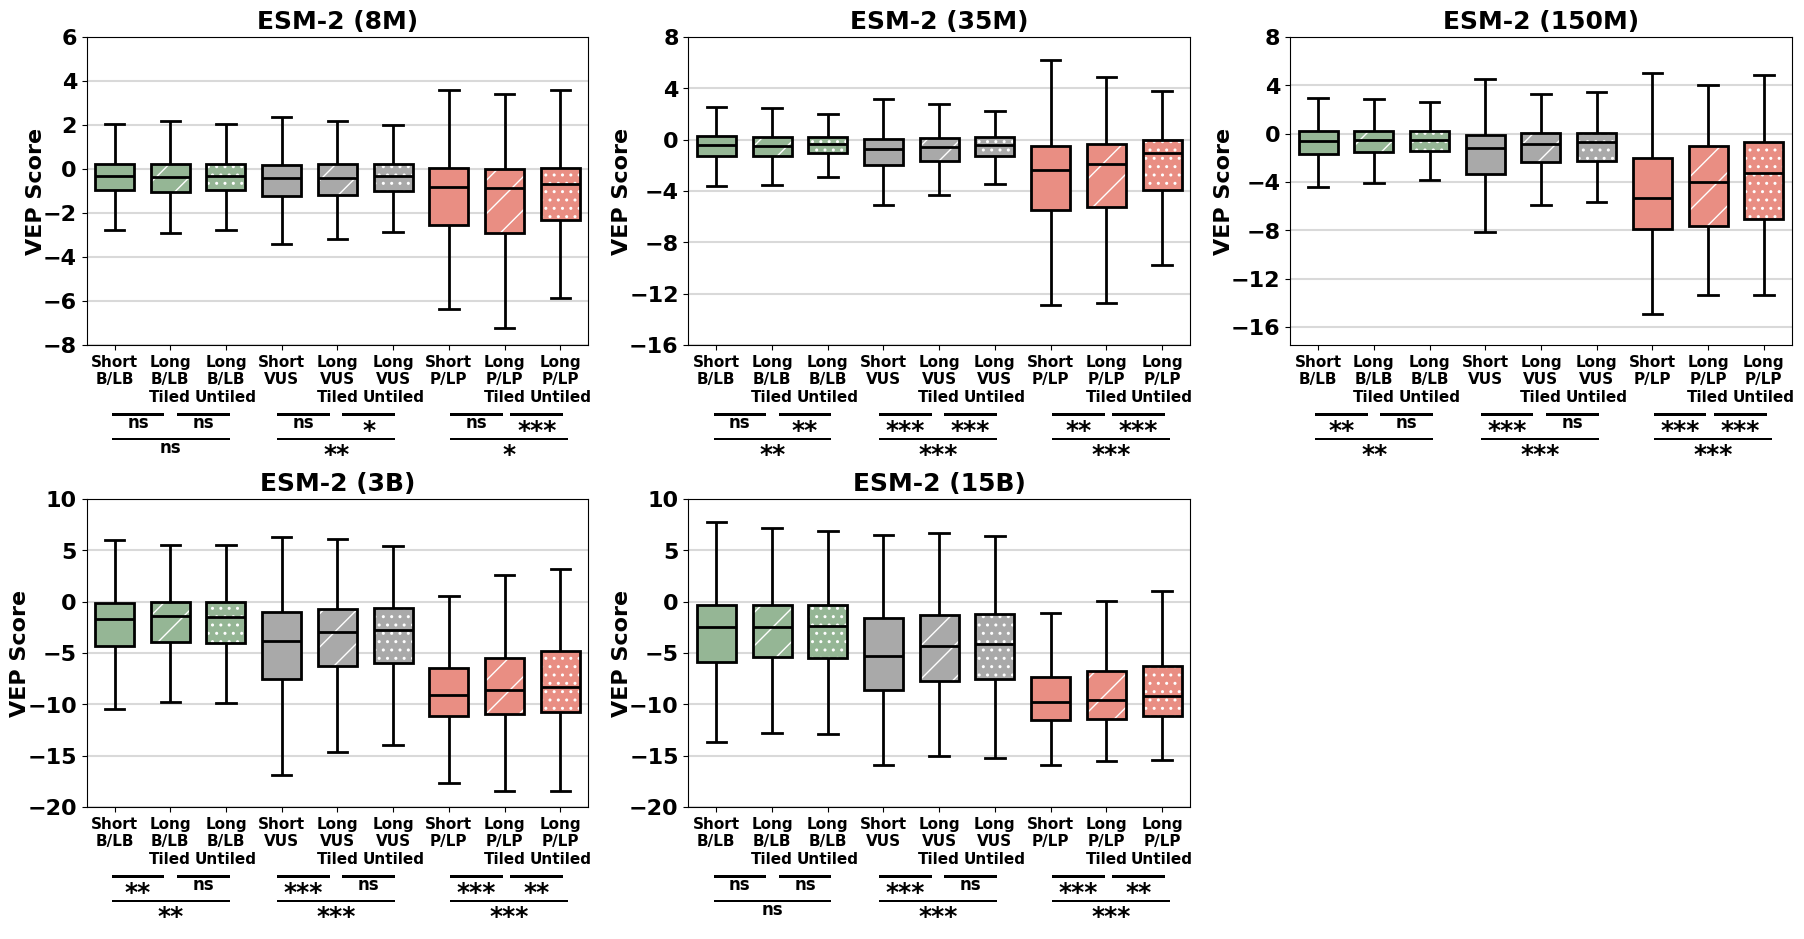

In [77]:
fig, axes = plt.subplots(2, 3, figsize = (22,10))
fig.subplots_adjust(hspace = 0.5)
axes = axes.ravel()

for i, chosen_model in enumerate(["esm_2_8M", "esm_2_35M", "esm_2_150M" , "esm_2",  "esm_2_15B"]):
    ax= axes[i]
    data = [
        model_to_blb_scores[chosen_model]["short_proteins"],
        model_to_blb_scores[chosen_model]["long_blb_tile"],
        model_to_blb_scores[chosen_model]["long_blb_rotary"],
        model_to_vus_scores[chosen_model]["short_proteins"],
        model_to_vus_scores[chosen_model]["long_vus_tile"],
        model_to_vus_scores[chosen_model]["long_vus_rotary"],
        model_to_plp_scores[chosen_model]["short_proteins"],
        model_to_plp_scores[chosen_model]["long_plp_tile"],
        model_to_plp_scores[chosen_model]["long_plp_rotary"],    
    ]

    sns.boxplot(
        data, 
        showfliers = False,
        palette = {
            0 : "darkseagreen",
            1: "darkseagreen",
            2 : "darkseagreen",
            3 : "darkgray",
            4: "darkgray",
            5 : "darkgray",
            6 : "salmon",
            7: "salmon",
            8 : "salmon",
        },
        boxprops = {"edgecolor" : "black", "linewidth": 2},
        medianprops = {"color" : "black", "linewidth": 2},
        whiskerprops = {"color" : "black", "linewidth": 2},
        capprops = {"color" : "black", "linewidth": 2}, 
        width = 0.7,
        ax=ax,
        zorder = 100
    )

    ax.set_yticks(ax.get_yticks())
    if chosen_model in ["esm_2_35M", "esm_2_150M"]:
        ax.set_yticks([-16,-12,-8,-4,0,4,8])
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold", fontsize = 16)

    ax.set_ylabel("VEP Score", fontsize = 16, fontweight = "bold", labelpad =-2)
    ax.set_xticklabels([
            "Short\nB/LB",
            "Long\nB/LB\nTiled",
            "Long\nB/LB\nUntiled",
            "Short\nVUS",
            "Long\nVUS\nTiled",
            "Long\nVUS\nUntiled",
            "Short\nP/LP",
            "Long\nP/LP\nTiled",
            "Long\nP/LP\nUntiled",
        ],
        fontsize = 11,
        fontweight = "bold"
    )

    hatch_list = ["", "/", ".."] * 3
    c_list = ["white", "white", "white"] * 3
    patches = ax.patches
    for i, (patch, hatch) in enumerate(zip(patches, hatch_list)):
        patch.set_hatch(hatch)
        patch._hatch_color = mcolors.to_rgba(c_list[i])

    ax.set_title(model_to_display_name[chosen_model], fontweight = "bold", fontsize = 18)
    
    for y_val in ax.get_yticks():
        ax.axhline(y = y_val, color = "black", alpha = 0.15, zorder = 1)

    list_positions_a = [0, 1, 0, 3, 4, 3, 6, 7, 6]
    list_positions_b = [1, 2, 2, 4, 5, 5, 7, 8, 8]
    lengths = [0.105, 0.105, 0.235,0.105, 0.105, 0.235,0.105, 0.105, 0.235]
    start_positions = [0.05, 0.18, 0.05, 0.38, 0.51, 0.38, 0.725, 0.845, 0.725]
    y_positions = [-0.23, -0.23, -0.31, -0.23, -0.23, -0.31, -0.23, -0.23, -0.31,]

    for index, start_pos in enumerate(start_positions):
        rect_length = lengths[index]
        rect_y_pos = y_positions[index]
        x_end_pos = start_pos + rect_length
        rect = mpatches.Rectangle((start_pos, rect_y_pos), rect_length, 0.0075, clip_on = False, facecolor = "black", transform=ax.transAxes)
        ax.add_patch(rect)

        st, p = scipy.stats.mannwhitneyu(data[list_positions_a[index]], data[list_positions_b[index]], alternative = "less")
        stars = p_val_to_stars(p)
        text_pos = start_pos  + ((x_end_pos - start_pos ) / 2)
        fs = 12 if stars == "ns" else 18
        y_offset = 0.04 if stars == "ns" else 0.07
        ax.text(text_pos, rect_y_pos - y_offset, stars, fontsize = fs, fontweight = "bold", transform = ax.transAxes, horizontalalignment = "center")
        
fig.delaxes(axes[-1])

In [78]:
model_to_key = {
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" : "ESM-2 (35M)",
    "esm_2_150M" : "ESM-2 (150M)",
    "esm_2_650M" : "ESM-2 (650M)",
    "esm_2" : "ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)",
    "esm_1b" : "ESM-1b (650M)",
    "esm_1v" : "ESM-1v (650M)",
    "esm_1_UR50" : "ESM-1 (670M) UR50S",
    "esm_1_UR50D" : "ESM-1 (670M) UR50D",
    "esm_1_UR100" : "ESM-1 (670M) UR100",
    "esm_1_43M" : "ESM-1 (43M) UR50",
    "esm_1_85M": "ESM-1 (85M) UR50",
    "protbert" : "ProtBERT"    
}


In [79]:
# assumption is scores_1 is lower (more pathogenic)

def get_argmax_accuracy_point(scores_1, scores_2):
    maximum_val = max(np.max(scores_1), np.max(scores_2))
    minimum_val = min(np.min(scores_1), np.min(scores_2))
    argmax = None 
    max_accuracy = float("-inf")
    argmax_conf = []
    
    for cutoff in np.arange(minimum_val, maximum_val, 0.01):
        true_positives = np.sum(scores_2 > cutoff)
        false_negatives = np.sum(scores_2 <= cutoff)
        
        true_negatives = np.sum(scores_1 <= cutoff)
        false_postitives =  np.sum(scores_1 > cutoff)
        
        total_obs = true_positives + false_negatives + true_negatives + false_postitives
        accuracy = (true_positives + true_negatives) / total_obs
        
        if accuracy > max_accuracy:
            max_accuracy = accuracy
            argmax = cutoff
            argmax_conf = [[true_positives, false_postitives], [false_negatives, true_negatives]]
    
    return max_accuracy, argmax, argmax_conf

# training just on short, using all of them not just train test splits ... 

In [80]:
# moved in favor other method below, just need this for the orange bar plot, remaining results aren't used. 

In [81]:
rotary_v_tile_results = {}

for model_choice in ["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]:
    
    needed_variants_df = pd.read_csv(llm_review_path + "figure_panels/submission/table_csvs/clinvar_misclassification_all_models_all_variants.csv")

    existing_clinvar_variant_scores = needed_variants_df.loc[
        needed_variants_df["model"] == model_to_key[model_choice]
    ]

    selected_train_variants = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (~existing_clinvar_variant_scores["is_long_protein"])
    ]


    train_plp = selected_train_variants.loc[selected_train_variants["clinvar_annotation"] == "PLP"]["score"].values
    train_blb = selected_train_variants.loc[selected_train_variants["clinvar_annotation"] == "BLB"]["score"].values

    train_plp_names = selected_train_variants.loc[selected_train_variants["clinvar_annotation"] == "PLP"]["full_name"].values
    train_blb_names = selected_train_variants.loc[selected_train_variants["clinvar_annotation"] == "BLB"]["full_name"].values
    
    max_acc, argmax_acc, argmax_cmat_train_short = get_argmax_accuracy_point(train_plp, train_blb)
    print("Train...", max_acc, argmax_acc, argmax_cmat_train_short)

    tiled_test_plp_df = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["is_long_protein"]) &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "PLP")
    ]
    
    tiled_test_plp = tiled_test_plp_df["score"].values
    
    tiled_test_blb_df = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["is_long_protein"]) &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "BLB")
    ]
    
    tiled_test_blb = tiled_test_blb_df["score"].values
    
    tiled_plp_dict = dict(zip(tiled_test_plp_df["full_name"].values , tiled_test_plp_df["score"].values))
    tiled_blb_dict = dict(zip(tiled_test_blb_df["full_name"].values , tiled_test_blb_df["score"].values))


    tp_tile = len(tiled_test_plp[tiled_test_plp <= argmax_acc])
    fn_tile = len(tiled_test_plp[tiled_test_plp > argmax_acc])

    tn_tile = len(tiled_test_blb[tiled_test_blb > argmax_acc])
    fp_tile = len(tiled_test_blb[tiled_test_blb <= argmax_acc])


    tiled_total_acc = (tp_tile + tn_tile) / (tp_tile + fn_tile + tn_tile + fp_tile)

    print(tiled_total_acc, tp_tile, fn_tile, tn_tile, fp_tile)

    rotary_clinvar_results = pd.read_csv("./clinvar_results_rotary/" + model_choice + "_selected_clinvar_long_with_VUS.csv", index_col = 0)
    
    if model_choice == "esm_2_15B":
        #could not fit on GPU, did these on CPU
        additional_variants = pd.read_csv(f"./clinvar_results_rotary/{model_choice}_selected_clinvar_long_MISSING_FROM_GPU.csv")
        rotary_clinvar_results = pd.concat([rotary_clinvar_results, additional_variants])
    
    rotary_clinvar_results = augment_clinvar_masked_df_with_site_entropy(rotary_clinvar_results)
    
    print("max min", np.max(rotary_clinvar_results['s1']), np.min(rotary_clinvar_results['s1']))
    
    rotary_clinvar_results["gene"] = rotary_clinvar_results["variant_name"].apply(lambda x : "_".join(x.split("_")[:2]))
    rotary_clinvar_results["full_name"] = rotary_clinvar_results["gene"] + "_" + rotary_clinvar_results.index
    rotary_clinvar_results = rotary_clinvar_results.drop_duplicates(subset = "full_name")

    needed_plp = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["is_long_protein"]) &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "PLP")
    ]["full_name"].values

    needed_blb = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["is_long_protein"]) &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "BLB")
    ]["full_name"].values

    rotary_scores_plp_df = rotary_clinvar_results.loc[rotary_clinvar_results["full_name"].isin(needed_plp)]
    rotary_scores_blb_df = rotary_clinvar_results.loc[rotary_clinvar_results["full_name"].isin(needed_blb)]

    rotary_scores_plp = rotary_scores_plp_df['s1'].values
    rotary_scores_blb = rotary_scores_blb_df['s1'].values
    
    rotary_plp_dict = dict(zip(rotary_scores_plp_df["full_name"].values, rotary_scores_plp_df["s1"].values))
    rotary_blb_dict = dict(zip(rotary_scores_blb_df["full_name"].values, rotary_scores_blb_df["s1"].values))
    
    
    
    print("min max 2 ", np.max(rotary_scores_plp), np.min(rotary_scores_plp))
    
    tp_rotary = len(rotary_scores_plp[rotary_scores_plp <= argmax_acc])
    fn_rotary = len(rotary_scores_plp[rotary_scores_plp > argmax_acc])

    tn_rotary = len(rotary_scores_blb[rotary_scores_blb > argmax_acc])
    fp_rotary = len(rotary_scores_blb[rotary_scores_blb <= argmax_acc])

    rotary_total_acc = (tp_rotary + tn_rotary) / (tp_rotary + fn_rotary + tn_rotary + fp_rotary)

    print(rotary_total_acc, tp_rotary, fn_rotary, tn_rotary, fp_rotary)
    
    
    max_acc_rotary_only, argmax_acc_rotary_only, rotary_only_cmat = get_argmax_accuracy_point(rotary_scores_plp, rotary_scores_blb)
    max_acc_tiled_only, argmax_acc_tiled_only, tile_only_cmat = get_argmax_accuracy_point(tiled_test_plp, tiled_test_blb)

    print("rotary_acc" , max_acc_rotary_only, argmax_acc_rotary_only)
    
    report_1_plp_names_test = []
    report_2_blb_names_test = []
    
    report_3_plp_scores_rotary = []
    report_4_plp_scores_tile = []
    
    report_5_blb_scores_rotary = []
    report_6_blb_scores_tile = []
    
    for k,v in rotary_plp_dict.items():
        report_1_plp_names_test.append(k)
        report_3_plp_scores_rotary.append(v)
        report_4_plp_scores_tile.append(tiled_plp_dict[k])
        
    for k,v in rotary_blb_dict.items():
        report_2_blb_names_test.append(k)
        report_5_blb_scores_rotary.append(v)
        report_6_blb_scores_tile.append(tiled_blb_dict[k])
    
    rotary_v_tile_results[model_choice] = {
        "short_protein_train_acc" : max_acc,
        "short_protein_argmax_acc" : argmax_acc,
        "short_protein_cmat" : argmax_cmat_train_short,
        "tp_rotary" : tp_rotary,
        "tn_rotary" : tn_rotary,
        "fn_rotary" : fn_rotary,
        "fp_rotary" : fp_rotary,
        "rotary_total_acc" : rotary_total_acc,
        "max_acc_rotary_only" : max_acc_rotary_only,
        "argmax_acc_rotary_only" : argmax_acc_rotary_only,
        "rotary_only_cmat" : rotary_only_cmat,
        "tp_tile" : tp_tile,
        "fn_tile" : fn_tile, 
        "tn_tile" : tn_tile, 
        "fp_tile" : fp_tile,
        "tiled_total_acc" : tiled_total_acc,
        "max_acc_tile_only" : max_acc_tiled_only,
        "tile_only_cmat" : tile_only_cmat,
        "argmax_acc_tiled_only" : argmax_acc_tiled_only,
        "train_plp" : train_plp, 
        "train_blb" : train_blb,
        "train_blb_names" : train_blb_names,
        "train_plp_names" : train_plp_names,
    }

Train... 0.618429003021148 -1.370454587208748 [[2783, 1999], [527, 1311]]
0.6141689373297002 747 1088 1507 328
max min 5.994265113124115 -14.069660180367213
min max 2  3.566580152767721 -11.672670461384904
0.5994550408719346 664 1171 1536 299
rotary_acc 0.6019073569482288 -1.4226704613851222
Train... 0.7034743202416919 -2.096409489769677 [[2879, 1532], [431, 1778]]
0.679291553133515 889 946 1604 231
max min 8.113375726809897 -15.607895787246942
min max 2  3.817131548623201 -13.920148798091951
0.6446866485013624 698 1137 1668 167
rotary_acc 0.6471389645776566 -1.5701487980922142
Train... 0.7832326283987915 -2.74127349299396 [[2872, 997], [438, 2313]]
0.738692098092643 1075 760 1636 199
max min 7.86351438863993 -16.760559085829655
min max 2  4.880667662516287 -13.377779042823638
0.7119891008174387 979 856 1634 201
rotary_acc 0.71716621253406 -2.2977790428238745
Train... 0.8238670694864049 -4.40244359715722 [[2842, 698], [468, 2612]]
0.788283378746594 1271 564 1622 213
max min 8.377886765

0.6201634877384197 0.6019073569482288
0.6814713896457766 0.6471389645776566
0.7403269754768392 0.71716621253406
0.7926430517711172 0.771117166212534
0.8043596730245232 0.7811989100817439
0.7948228882833788 0.776566757493188


/tmp/ipykernel_2918821/3621896099.py:37: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch1 = mpatches.Patch(color = "darkorange", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein Tiled (Train)')
/tmp/ipykernel_2918821/3621896099.py:43: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch2 = mpatches.Patch(color = "darkorange", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein Untiled (Train)')


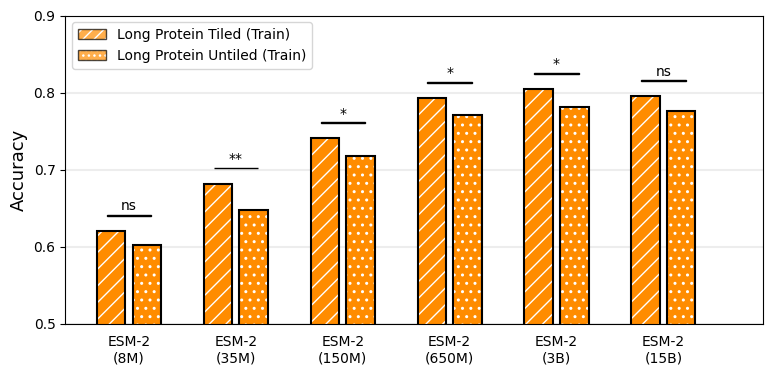

In [82]:
fig, ax = plt.subplots(figsize = (9,4))

data = []
labels = []
x = []

x_counter = 0
for m, results in rotary_v_tile_results.items():
    labels.append(model_to_key[m])
    print(results["max_acc_tile_only"], results["max_acc_rotary_only"])
    data.append(results["max_acc_tile_only"])
    data.append(results["max_acc_rotary_only"])
    data.append(0)

    
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    
    
ax.bar(x, data, color = "darkorange", edgecolor = "black", alpha = 1, linewidth = 1.5)
ax.set_yticks([0.5,0.6,0.7,0.8,0.9])
ax.set_ylim(bottom=0.5, top = 0.9)

ax.set_xticks([])

hatch_list = ["//", "..", ""] * len(rotary_v_tile_results)
patches = ax.patches
for patch, hatch in zip(patches, hatch_list):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba("white")
    

patch1 = mpatches.Patch(color = "darkorange", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein Tiled (Train)')
patch1.set_hatch("///")
patch1.set_edgecolor("black")
patch1._hatch_color = mcolors.to_rgba("white")


patch2 = mpatches.Patch(color = "darkorange", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein Untiled (Train)')
patch2.set_hatch("...")
patch2.set_edgecolor("black")
patch2._hatch_color = mcolors.to_rgba("white")

plt.legend(handles=[patch1, patch2], loc = "upper left")

counter = 0
for i in np.arange(1, 3*len(labels), 3):
    ax.text(i-0.5, 0.45, labels[counter].replace(" ", "\n"), horizontalalignment = "center")
    counter += 1

y_offset_1 = 0.02
for i, (m, results) in enumerate(rotary_v_tile_results.items()):
    
    rotary_only_cmat = results["rotary_only_cmat"]
    tile_only_cmat = results["tile_only_cmat"]
    
    correct_rotary = rotary_only_cmat[0][0] + rotary_only_cmat[1][1]
    incorrect_rotary = rotary_only_cmat[1][0] + rotary_only_cmat[0][1]
    
    correct_tile = tile_only_cmat[0][0] + tile_only_cmat[1][1]
    incorrect_tile = tile_only_cmat[1][0] + tile_only_cmat[0][1]
    
    y1 = data[i*3]
    y2 = data[(i*3) + 1]
    
    point_1 = max(y1,y2) + y_offset_1 
    rect = mpatches.Rectangle(((i*3) - 0.125, point_1), 1.25, 0.001, color = "black")
    ax.add_patch(rect)
    
    chi_sq_1 = scipy.stats.chi2_contingency([
        [correct_rotary, incorrect_rotary],
        [correct_tile, incorrect_tile]
    ])[1]
    
    stars_1 = p_val_to_stars(chi_sq_1)
    ax.text((i*3) + 0.5, point_1 + 0.007, stars_1, horizontalalignment = "center")
    
    
ax.set_ylabel("Accuracy", fontsize = 13)

for y_tick in ax.get_yticks():
    ax.axhline(y = y_tick, zorder = 0, color = "black", alpha = 0.07)

In [83]:
rotary_v_tile_results_alt = {}

needed_variants_df = pd.read_csv(llm_review_path + "figure_panels/submission/table_csvs/clinvar_misclassification_all_models_all_variants.csv")

### getting trian and test variants, can choose any model

existing_clinvar_variant_scores = needed_variants_df.loc[
    needed_variants_df["model"] == model_to_key["esm_2"]
]

selected_train_variants = existing_clinvar_variant_scores.loc[
    (existing_clinvar_variant_scores["used_in_classification"]) &
    (~existing_clinvar_variant_scores["is_long_protein"])
]

num_unique_short_genes = len(set(selected_train_variants["gene_name"].values))

train_short_genes = selected_train_variants.drop_duplicates(subset = "gene_name").sample(frac = 1, random_state = 2025).head(num_unique_short_genes // 2)["gene_name"].values
test_short_genes = selected_train_variants.loc[~selected_train_variants["gene_name"].isin(train_short_genes)].drop_duplicates(subset = "gene_name")["gene_name"].values

print(len(train_short_genes),len(test_short_genes))

331 331


In [84]:


for model_choice in ["esm_2_8M", "esm_2_35M", "esm_2_150M", "esm_2_650M", "esm_2", "esm_2_15B"]:
    
    needed_variants_df = pd.read_csv(llm_review_path + "figure_panels/submission/table_csvs/clinvar_misclassification_all_models_all_variants.csv")

    existing_clinvar_variant_scores = needed_variants_df.loc[
        needed_variants_df["model"] == model_to_key[model_choice]
    ]

    selected_train_variants = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["gene_name"].isin(train_short_genes)) 
    ]
    
    train_plp_df = selected_train_variants.loc[selected_train_variants["clinvar_annotation"] == "PLP"]
    train_blb_df = selected_train_variants.loc[selected_train_variants["clinvar_annotation"] == "BLB"]
    
    train_plp_names = dict(zip(train_plp_df["full_name"].values, train_plp_df["score"].values))
    train_blb_names = dict(zip(train_blb_df["full_name"].values, train_blb_df["score"].values))
    
    train_plp = train_plp_df["score"].values
    train_blb = train_blb_df["score"].values

    max_acc, argmax_acc, argmax_cmat_train_short = get_argmax_accuracy_point(train_plp, train_blb)
    print(len(train_plp), len(train_blb), len(train_short_genes), len(test_short_genes))
    print("Train...", max_acc, argmax_acc, argmax_cmat_train_short)

    ##################### testing sets 
    
    short_test_plp_df = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (~existing_clinvar_variant_scores["is_long_protein"]) & # was commented
        (~existing_clinvar_variant_scores["gene_name"].isin(train_short_genes))  &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "PLP")
    ]
        
    
    
    short_test_plp = short_test_plp_df["score"].values
    
    short_test_plp_names = dict(zip(short_test_plp_df["full_name"].values, short_test_plp_df["score"].values))
    
    short_test_blb_df = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (~existing_clinvar_variant_scores["is_long_protein"]) & # was commented
        (~existing_clinvar_variant_scores["gene_name"].isin(train_short_genes))  &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "BLB")
    ]
    
    short_test_blb_names = dict(zip(short_test_blb_df["full_name"].values, short_test_blb_df["score"].values))
    
    short_test_blb = short_test_blb_df["score"].values
    
    tp_short_test = len(short_test_plp[short_test_plp <= argmax_acc])
    fn_short_test = len(short_test_plp[short_test_plp > argmax_acc])

    tn_short_test = len(short_test_blb[short_test_blb > argmax_acc])
    fp_short_test = len(short_test_blb[short_test_blb <= argmax_acc])


    short_test_total_acc = (tp_short_test + tn_short_test) / (tp_short_test + fn_short_test + tn_short_test + fp_short_test)
    
    short_test_cmat = [[tp_short_test, fp_short_test], [fn_short_test , tn_short_test]]
    print("short test acc", short_test_total_acc, tp_short_test, fn_short_test, tn_short_test, fp_short_test)

    
    tiled_test_plp_df = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["is_long_protein"]) &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "PLP") 
    ]
    
    tiled_test_plp_names = dict(zip(tiled_test_plp_df["full_name"].values, tiled_test_plp_df["score"].values))
    
    tiled_test_plp = tiled_test_plp_df["score"].values

    tiled_test_blb_df  = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["is_long_protein"]) &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "BLB")
    ]
    
    tiled_test_blb_names = dict(zip(tiled_test_blb_df["full_name"].values, tiled_test_blb_df["score"].values))
    
    tiled_test_blb = tiled_test_blb_df["score"].values


    tp_tile = len(tiled_test_plp[tiled_test_plp <= argmax_acc])
    fn_tile = len(tiled_test_plp[tiled_test_plp > argmax_acc])

    tn_tile = len(tiled_test_blb[tiled_test_blb > argmax_acc])
    fp_tile = len(tiled_test_blb[tiled_test_blb <= argmax_acc])


    tiled_total_acc = (tp_tile + tn_tile) / (tp_tile + fn_tile + tn_tile + fp_tile)

    print(tiled_total_acc, tp_tile, fn_tile, tn_tile, fp_tile)

    rotary_clinvar_results = pd.read_csv("./clinvar_results_rotary/" + model_choice + "_selected_clinvar_long_with_VUS.csv", index_col = 0)
    
    if model_choice == "esm_2_15B":
        #could not fit on GPU, did these on CPU
        additional_variants = pd.read_csv(f"./clinvar_results_rotary/{model_choice}_selected_clinvar_long_MISSING_FROM_GPU.csv")
        rotary_clinvar_results = pd.concat([rotary_clinvar_results, additional_variants])
    
    rotary_clinvar_results = augment_clinvar_masked_df_with_site_entropy(rotary_clinvar_results)
    
    print("max min", np.max(rotary_clinvar_results['s1']), np.min(rotary_clinvar_results['s1']))
    
    rotary_clinvar_results["gene"] = rotary_clinvar_results["variant_name"].apply(lambda x : "_".join(x.split("_")[:2]))
    rotary_clinvar_results["full_name"] = rotary_clinvar_results["gene"] + "_" + rotary_clinvar_results.index
    rotary_clinvar_results = rotary_clinvar_results.drop_duplicates(subset = "full_name")

    needed_plp = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["is_long_protein"]) &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "PLP") 
    ]["full_name"].values

    needed_blb = existing_clinvar_variant_scores.loc[
        (existing_clinvar_variant_scores["used_in_classification"]) &
        (existing_clinvar_variant_scores["is_long_protein"]) &
        (existing_clinvar_variant_scores["clinvar_annotation"] == "BLB")
    ]["full_name"].values
    
    rotary_plp_df = rotary_clinvar_results.loc[rotary_clinvar_results["full_name"].isin(needed_plp)]
    rotary_blb_df = rotary_clinvar_results.loc[rotary_clinvar_results["full_name"].isin(needed_blb)]

    rotary_plp_names = dict(zip(rotary_plp_df["full_name"].values, rotary_plp_df["s1"].values))
    rotary_blb_names = dict(zip(rotary_blb_df["full_name"].values, rotary_blb_df["s1"].values))
    
    rotary_scores_plp = rotary_plp_df['s1'].values
    rotary_scores_blb = rotary_blb_df['s1'].values
    
    print("long stats : ", len(rotary_scores_plp), len(rotary_scores_blb), len(set(rotary_clinvar_results["gene"])))
    print("min max 2 ", np.max(rotary_scores_plp), np.min(rotary_scores_plp))
    tp_rotary = len(rotary_scores_plp[rotary_scores_plp <= argmax_acc])
    fn_rotary = len(rotary_scores_plp[rotary_scores_plp > argmax_acc])

    tn_rotary = len(rotary_scores_blb[rotary_scores_blb > argmax_acc])
    fp_rotary = len(rotary_scores_blb[rotary_scores_blb <= argmax_acc])

    rotary_total_acc = (tp_rotary + tn_rotary) / (tp_rotary + fn_rotary + tn_rotary + fp_rotary)

    print(rotary_total_acc, tp_rotary, fn_rotary, tn_rotary, fp_rotary)
    
    max_acc_rotary_only, argmax_acc_rotary_only, rotary_only_cmat = get_argmax_accuracy_point(rotary_scores_plp, rotary_scores_blb)
    max_acc_tiled_only, argmax_acc_tiled_only, tile_only_cmat = get_argmax_accuracy_point(tiled_test_plp, tiled_test_blb)

    print("rotary_acc" , max_acc_rotary_only, argmax_acc_rotary_only)
    
    report_1_test_blb_long_names = []
    report_2_test_plp_long_names = []
    
    report_3_test_blb_long_scores_tiled = []
    report_4_test_plp_long_scores_tiled = []
    
    report_5_test_blb_long_scores_rotary = []
    report_6_test_plp_long_scores_rotary = []
    
    
    
    for k, v in rotary_plp_names.items():
        report_6_test_plp_long_scores_rotary.append(v)
        report_2_test_plp_long_names.append(k)
        report_4_test_plp_long_scores_tiled.append(tiled_test_plp_names[k])
        
    for k, v in rotary_blb_names.items():
        report_5_test_blb_long_scores_rotary.append(v)
        report_1_test_blb_long_names.append(k)
        report_3_test_blb_long_scores_tiled.append(tiled_test_blb_names[k])
    
    
    rotary_v_tile_results_alt[model_choice] = {
        "short_protein_train_acc" : max_acc,
        "short_protein_argmax_acc" : argmax_acc,
        "short_protein_cmat" : argmax_cmat_train_short,
        "tp_rotary" : tp_rotary,
        "tn_rotary" : tn_rotary,
        "fn_rotary" : fn_rotary,
        "fp_rotary" : fp_rotary,
        "rotary_total_acc" : rotary_total_acc,
        "max_acc_rotary_only" : max_acc_rotary_only,
        "argmax_acc_rotary_only" : argmax_acc_rotary_only,
        "rotary_only_cmat" : rotary_only_cmat,
        "tp_tile" : tp_tile,
        "fn_tile" : fn_tile, 
        "tn_tile" : tn_tile, 
        "fp_tile" : fp_tile,
        "tiled_total_acc" : tiled_total_acc,
        "max_acc_tile_only" : max_acc_tiled_only,
        "tile_only_cmat" : tile_only_cmat,
        "argmax_acc_tiled_only" : argmax_acc_tiled_only,
        "tp_short_test" : tp_short_test,
        "tn_short_test" : tn_short_test,
        "fn_short_test" : fn_short_test,
        "fp_short_test" : fp_short_test,
        "short_test_total_acc" : short_test_total_acc,
        "short_test_cmat" : short_test_cmat,
        "short_train_plp_scores" : train_plp,
        "short_train_blb_scores" : train_blb,
        "short_train_variant_names_blb" : list(train_blb_names.keys()),
        "short_train_variant_scores_blb" : list(train_blb_names.values()),
        "short_train_variant_names_plp" : list(train_plp_names.keys()),
        "short_train_variant_scores_plp" : list(train_plp_names.values()),
        
        "short_test_variant_names_blb":  list(short_test_blb_names.keys()),
        "short_test_variant_scores_blb":  list(short_test_blb_names.values()),
        "short_test_variant_names_plp":  list(short_test_plp_names.keys()),
        "short_test_variant_scores_plp":  list(short_test_plp_names.values()),
        
        "long_test_variant_names_plp" : report_2_test_plp_long_names,
        "long_test_variant_names_blb" : report_1_test_blb_long_names,
        "long_test_variant_scores_plp_rotary" : report_6_test_plp_long_scores_rotary,
        "long_test_variant_scores_plp_tiled" : report_4_test_plp_long_scores_tiled,
        "long_test_variant_scores_blb_rotary" : report_5_test_blb_long_scores_rotary,
        "long_test_variant_scores_blb_tiled" : report_3_test_blb_long_scores_tiled,
        
    }

1655 1655 331 331
Train... 0.6084592145015105 -1.6204545872087426 [[1445, 1086], [210, 569]]
short test acc 0.6232628398791541 614 1041 1449 206
0.6190735694822889 678 1157 1594 241
max min 5.994265113124115 -14.069660180367213
long stats :  1835 1835 367
min max 2  3.566580152767721 -11.672670461384904
0.5997275204359673 596 1239 1605 230
rotary_acc 0.6019073569482288 -1.4226704613851222
1655 1655 331 331
Train... 0.6930513595166163 -1.916312883320133 [[1411, 772], [244, 883]]
short test acc 0.7126888217522659 954 701 1405 250
0.6811989100817438 922 913 1578 257
max min 8.113375726809897 -15.607895787246942
long stats :  1835 1835 367
min max 2  3.817131548623201 -13.920148798091951
0.6444141689373297 734 1101 1631 204
rotary_acc 0.6471389645776566 -1.5701487980922142
1655 1655 331 331
Train... 0.7779456193353474 -3.0012734929939544 [[1459, 539], [196, 1116]]
short test acc 0.7879154078549849 1126 529 1482 173
0.7354223433242507 1036 799 1663 172
max min 7.86351438863993 -16.760559085

In [85]:
import copy 


model_to_display_str = {
    "esm_2_8M" : "ESM-2 (8M)",
    "esm_2_35M" : "ESM-2 (35M)",
    "esm_2_150M" : "ESM-2 (150M)",
    "esm_2_650M" : "ESM-2 (650M)",
    "esm_2" : "ESM-2 (3B)",
    "esm_2_15B" : "ESM-2 (15B)",
}

supp_table_res = []

keeping_columns = []


for model, vals in rotary_v_tile_results_alt.items():
    v1 = copy.deepcopy(vals)
    v1.pop("short_train_plp_scores")
    v1.pop("short_train_blb_scores")
    to_report = {}
    to_report["model"] = model_to_display_str[model] 
    for k, v in vals.items():
        
        if "scores" in k:
            v = "|".join(list(map(lambda x : str(round(x, 6)), v)))
            print(k, len(v.split("|")))
        elif "names" in k:
            v = "|".join(v)
            
        elif "short_protein_argmax_acc" == k:
            k = "phi_m_short_protein_argmax_acc"
        elif "cmat" in k:
            continue 
            
        to_report[k] = v
        
    vus_short = dict(zip(model_to_vus_scores[model]["short_proteins_vus_names"] , model_to_vus_scores[model]["short_proteins"]))
    
    x1,x2 = [], []
    
    for vn, sc in vus_short.items():
        x1.append(vn)
        x2.append(str(sc))
        
    to_report["variant_names_vus_short"] = "|".join(x1)
    to_report["variant_scores_vus_short"] = "|".join(x2)
    
    x3, x4, x5 = [],[],[]
    vus_long_tiled = dict(zip(model_to_vus_scores[model]["long_vus_tile_names"] , model_to_vus_scores[model]["long_vus_tile"]))
    vus_long_rotary = dict(zip(model_to_vus_scores[model]["long_vus_rotary_names"] ,model_to_vus_scores[model]["long_vus_rotary"]))
    
    
    for vn, sc in vus_long_tiled.items():
        x3.append(vn)
        x4.append(str(sc))
        x5.append(str(vus_long_rotary[vn]))
        
        
    
    to_report["variant_names_vus_long"] = "|".join(x3)
    to_report["variant_scores_vus_long_tiled"] = "|".join(x4)
    to_report["variant_names_vus_long_rotary"] = "|".join(x5)
    print(model, "variant_names_vus_long", len(x3))
    print(model, "variant_scores_vus_long_tiled", len(x4))
    print(model, "variant_names_vus_long_rotary", len(x5))
    
    supp_table_res.append(to_report)
    
supp_table_res_df = pd.DataFrame(supp_table_res)

short_train_plp_scores 1655
short_train_blb_scores 1655
short_train_variant_scores_blb 1655
short_train_variant_scores_plp 1655
short_test_variant_scores_blb 1655
short_test_variant_scores_plp 1655
long_test_variant_scores_plp_rotary 1835
long_test_variant_scores_plp_tiled 1835
long_test_variant_scores_blb_rotary 1835
long_test_variant_scores_blb_tiled 1835
esm_2_8M variant_names_vus_long 1835
esm_2_8M variant_scores_vus_long_tiled 1835
esm_2_8M variant_names_vus_long_rotary 1835
short_train_plp_scores 1655
short_train_blb_scores 1655
short_train_variant_scores_blb 1655
short_train_variant_scores_plp 1655
short_test_variant_scores_blb 1655
short_test_variant_scores_plp 1655
long_test_variant_scores_plp_rotary 1835
long_test_variant_scores_plp_tiled 1835
long_test_variant_scores_blb_rotary 1835
long_test_variant_scores_blb_tiled 1835
esm_2_35M variant_names_vus_long 1835
esm_2_35M variant_scores_vus_long_tiled 1835
esm_2_35M variant_names_vus_long_rotary 1835
short_train_plp_scores 1655

In [86]:
supp_table_res_df.to_csv(supp_table_path + "clinvar_misclass_summary_stats_with_scores_rotary_tiled.csv")

In [87]:
supp_table_res_df.iloc[0]

model                                                                         ESM-2 (8M)
short_protein_train_acc                                                         0.608459
phi_m_short_protein_argmax_acc                                                 -1.620455
tp_rotary                                                                            596
tn_rotary                                                                           1605
fn_rotary                                                                           1239
fp_rotary                                                                            230
rotary_total_acc                                                                0.599728
max_acc_rotary_only                                                             0.601907
argmax_acc_rotary_only                                                          -1.42267
tp_tile                                                                              678
fn_tile              

esm_2_8M 0.6232628398791541
esm_2_35M 0.7126888217522659
esm_2_150M 0.7879154078549849
esm_2_650M 0.8268882175226586
esm_2 0.8154078549848942
esm_2_15B 0.802416918429003


/tmp/ipykernel_2918821/1212730000.py:38: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch0 = mpatches.Patch(color = "powderblue", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Short Protein (Test)')
/tmp/ipykernel_2918821/1212730000.py:41: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch1 = mpatches.Patch(color = "powderblue",edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein Tiled (Test)')
/tmp/ipykernel_2918821/1212730000.py:47: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch2 = mpatches.Patch(color = "powderblue", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein Untiled (Test)')


(0.5, 0.98)

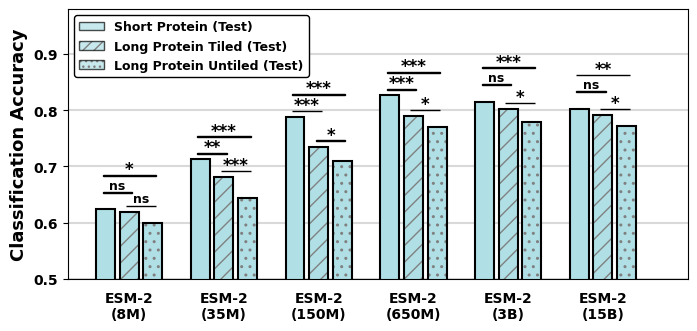

In [88]:
fig, ax = plt.subplots(figsize = (8,3.5))

data = []
labels = []
x = []

x_counter = 0
for m, results in rotary_v_tile_results_alt.items():
    labels.append(model_to_key[m])
    print(m, results["short_test_total_acc"])
    data.append(results["short_test_total_acc"])
    data.append(results["tiled_total_acc"])
    data.append(results["rotary_total_acc"])
    data.append(0)
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    

ax.bar(x, data, color = "powderblue", edgecolor = "black", alpha = 1, linewidth = 1.5)
ax.set_yticks([0.5,0.6,0.7,0.8,0.9])
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_ylim(bottom=0.5)

ax.set_xticks([])

hatch_list = ["", "//", "..", ""] * len(rotary_v_tile_results_alt)
patches = ax.patches
for patch, hatch in zip(patches, hatch_list):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba("gray")

patch0 = mpatches.Patch(color = "powderblue", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Short Protein (Test)')
patch0.set_edgecolor("black")

patch1 = mpatches.Patch(color = "powderblue",edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein Tiled (Test)')
patch1.set_hatch("///")
patch1.set_edgecolor("black")
patch1._hatch_color = mcolors.to_rgba("gray")


patch2 = mpatches.Patch(color = "powderblue", edgecolor = "black", linewidth = 1, alpha = 0.7, label='Long Protein Untiled (Test)')
patch2.set_hatch("...")
patch2.set_edgecolor("black")
patch2._hatch_color = mcolors.to_rgba("gray")

legend = ax.legend(
    handles=[patch0, patch1, patch2],  
    handlelength=2.,
    prop={'weight': 'bold', 'size' : 9},
    loc = "upper left",
    edgecolor = "black",
    framealpha=1
)




counter = 0
for i in np.arange(1, 4*len(labels), 4):
    ax.text(i, 0.43, labels[counter].replace(" ", "\n"), horizontalalignment = "center", fontweight = "bold")
    counter += 1
    
y_offset_1 = 0.01


for i, (m, results) in enumerate(rotary_v_tile_results_alt.items()):
   
    y1 = results["short_test_total_acc"]
    y2 = results["tiled_total_acc"]
    y3 = results["rotary_total_acc"]
    
    
    total_correct_tiled = results["tp_tile"] + results["tn_tile"]
    total_incorrect_tiled = results["fp_tile"] + results["fn_tile"]
    
    total_correct_non_tiled = results["tp_rotary"] + results["tn_rotary"]
    total_incorrect_non_tiled = results["fp_rotary"] + results["fn_rotary"]
    
    point_0 = max(y2, y3) + y_offset_1 
    
    rect = mpatches.Rectangle(((i*4) + 1 - 0.125, point_0), 1.25, 0.001, color = "black")
    ax.add_patch(rect)
    
    chi_sq_0 = scipy.stats.chi2_contingency([
        [total_correct_non_tiled, total_incorrect_non_tiled],
        [total_correct_tiled, total_incorrect_tiled]
    ])[1]
    
    stars_0 = p_val_to_stars(chi_sq_0)
    fs = 9 if stars_0 == "ns" else 12
    
    star_offset = 0.007 if stars_0 == "ns" else 0.002
    ax.text((i*4) + 1.5, point_0 + star_offset, stars_0, fontweight = "bold", horizontalalignment = "center", fontsize = fs)
    
    
    point_1 = max(y1,y2) + y_offset_1 
    
    if abs(point_0 - point_1) < 0.015:
        point_1 += 0.02
        
    rect = mpatches.Rectangle(((i*4) - 0.125, point_1), 1.25, 0.001, color = "black")
    ax.add_patch(rect)
    
    
    total_correct_short = results["short_test_cmat"][0][0] + results["short_test_cmat"][1][1] 
    total_incorrect_short = results["short_test_cmat"][1][0] + results["short_test_cmat"][0][1] 
    
    total_correct_tiled = results["tp_tile"] + results["tn_tile"]
    total_incorrect_tiled = results["fp_tile"] + results["fn_tile"]
    chi_sq_1 = scipy.stats.chi2_contingency([
        [total_correct_short, total_incorrect_short],
        [total_correct_tiled, total_incorrect_tiled]
    ])[1]
    
    stars_1 = p_val_to_stars(chi_sq_1)
    fs = 9 if stars_1 == "ns" else 12
    
    star_offset = 0.007 if stars_1 == "ns" else 0.002
    
    ax.text((i*4) + 0.5, point_1 + star_offset, stars_1, fontweight = "bold", horizontalalignment = "center", fontsize = fs)
    
    point_2 = max(y1,y3) + y_offset_1 
    
    if point_2 < point_1 : 
        point_2 = point_1 + 0.03
    
    if abs(point_1 - point_2) < 0.01:
        point_2 += 0.03
        
    
        
    rect = mpatches.Rectangle(((i*4) - 0.125, point_2), 2.25, 0.001, color = "black")
    ax.add_patch(rect)
    
    total_correct_non_tiled = results["tp_rotary"] + results["tn_rotary"]
    total_incorrect_non_tiled = results["fp_rotary"] + results["fn_rotary"]
    
    chi_sq_2 = scipy.stats.chi2_contingency([
        [total_correct_short, total_incorrect_short],
        [total_correct_non_tiled, total_incorrect_non_tiled]
    ])[1]
    
    stars_2 = p_val_to_stars(chi_sq_2)
    star_offset = 0.007 if stars_2 == "ns" else 0.002
    fs = 9 if stars_2 == "ns" else 12
    ax.text((i*4) + 1, point_2 + star_offset, stars_2, fontweight = "bold", horizontalalignment = "center", fontsize = fs)
    
ax.set_ylabel("Classification Accuracy", fontsize = 13, fontweight = "bold")

for y_tick in ax.get_yticks():
    ax.axhline(y = y_tick, zorder = 0, color = "black", alpha = 0.15)

ax.set_ylim(top = 0.98)

/tmp/ipykernel_2918821/1242584062.py:49: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch0 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 1, label='Short Protein (Test)')
/tmp/ipykernel_2918821/1242584062.py:52: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch1 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 1, label='Long Protein Tiled (Test)')
/tmp/ipykernel_2918821/1242584062.py:58: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch2 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 1, label='Long Protein Untiled (Test)')


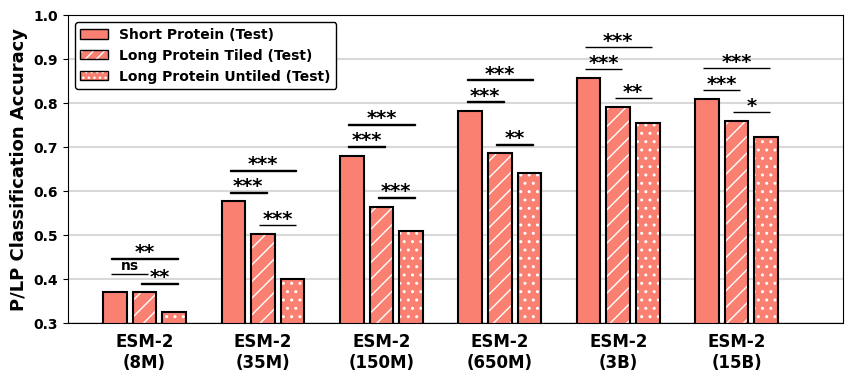

In [89]:
fig, ax = plt.subplots(figsize = (10,4))

data = []
labels = []
x = []

x_counter = 0
for m, results in rotary_v_tile_results_alt.items():
    labels.append(model_to_key[m])
    
    tp_short = results["short_test_cmat"][0][0]
    fn_short = results["short_test_cmat"][1][0] 
    
    tp_tiled = results["tp_tile"]
    fn_tiled = results["fn_tile"]
    
    tp_rotary = results["tp_rotary"]
    fn_rotary = results["fn_rotary"]
    
    data.append(tp_short / (tp_short+fn_short))
    data.append(tp_tiled / (tp_tiled + fn_tiled))
    data.append(tp_rotary / (tp_rotary + fn_rotary))
    data.append(0)
    
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    

ax.bar(x, data, color = "salmon", edgecolor = "black", alpha = 1, linewidth = 1.5)
ax.set_yticks([0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0])
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")
ax.set_ylim(bottom=0.3)


ax.set_xticks([])

hatch_list = ["", "//", "..", ""] * len(rotary_v_tile_results_alt)
patches = ax.patches
for patch, hatch in zip(patches, hatch_list):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba("white")

patch0 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 1, label='Short Protein (Test)')
patch0.set_edgecolor("black")

patch1 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 1, label='Long Protein Tiled (Test)')
patch1.set_hatch("///")
patch1.set_edgecolor("black")
patch1._hatch_color = mcolors.to_rgba("white")


patch2 = mpatches.Patch(color = "salmon", edgecolor = "black", linewidth = 1, alpha = 1, label='Long Protein Untiled (Test)')
patch2.set_hatch("...")
patch2.set_edgecolor("black")
patch2._hatch_color = mcolors.to_rgba("white")

plt.legend(
    handles=[patch0, patch1, patch2], 
    loc = "upper left",
    prop={'weight': 'bold', 'size' : 10},
    edgecolor = "black",
    framealpha=1
)


counter = 0
for i in np.arange(1, 4*len(labels), 4):
    ax.text(i, 0.2, labels[counter].replace(" ", "\n"), fontsize = 12, horizontalalignment = "center", fontweight = "bold")
    counter += 1

    
y_offset_1 = 0.02

for i, (m, results) in enumerate(rotary_v_tile_results_alt.items()):
    
    tp_short = results["short_test_cmat"][0][0]
    fn_short = results["short_test_cmat"][1][0] 
    
    tp_tiled = results["tp_tile"]
    fn_tiled = results["fn_tile"]
    
    tp_rotary = results["tp_rotary"]
    fn_rotary = results["fn_rotary"]
    
    
    y1 = data[i*4]
    y2 = data[(i*4) + 1]
    y3 = data[(i*4) + 2]
    
    
    point_0 = max(y2, y3) + y_offset_1 
    
    rect = mpatches.Rectangle(((i*4) + 1 - 0.125, point_0), 1.25, 0.001, color = "black")
    ax.add_patch(rect)
    
    chi_sq_0 = scipy.stats.chi2_contingency([
        [tp_tiled, fn_tiled],
        [tp_rotary, fn_rotary]
    ])[1]
    
    stars_0 = p_val_to_stars(chi_sq_0)
    
    star_offset = 0.009 if stars_0 == "ns" else 0.002
    fs = 10 if stars_0 == "ns" else 14
    star_offset = 0.01 if stars_0 == "ns" else 0.002
    ax.text((i*4) + 1.5, point_0 + star_offset, stars_0, fontsize = fs, horizontalalignment = "center", fontweight = "bold")
    
    
    point_1 = max(y1,y2) + y_offset_1 
    
    if abs(point_0 - point_1) < 0.015:
        point_1 += 0.02
    
    rect = mpatches.Rectangle(((i*4) - 0.125, point_1), 1.25, 0.001, color = "black")
    ax.add_patch(rect)

    
    chi_sq_1 = scipy.stats.chi2_contingency([
        [tp_short, fn_short],
        [tp_tiled, fn_tiled]
    ])[1]
    
    stars_1 = p_val_to_stars(chi_sq_1)
    fs = 10 if stars_1 == "ns" else 14
    star_offset = 0.01 if stars_1 == "ns" else 0.002
    ax.text((i*4) + 0.5, point_1 + star_offset, stars_1, fontsize = fs, fontweight = "bold", horizontalalignment = "center")
    
    
    point_2 = max(y1,y3) + y_offset_1 
    
    if abs(point_1 - point_2) < 0.01:
        point_2 += 0.05
        
    if point_2 < point_1 : 
        point_2 += 0.055
        
    rect = mpatches.Rectangle(((i*4) - 0.125, point_2), 2.25, 0.001, color = "black")
    ax.add_patch(rect)
    chi_sq_2 = scipy.stats.chi2_contingency([
        [tp_short, fn_short],
        [tp_rotary, fn_rotary]
    ])[1]
    stars_2 = p_val_to_stars(chi_sq_2)
    fs = 10 if stars_2 == "ns" else 14
    star_offset = 0.01 if stars_2 == "ns" else 0.002
    ax.text((i*4) + 1, point_2 + star_offset, stars_2, fontsize = fs, fontweight = "bold",  horizontalalignment = "center")
    
ax.set_ylabel("P/LP Classification Accuracy", fontsize = 13, fontweight = "bold")

for y_tick in ax.get_yticks():
    ax.axhline(y = y_tick, zorder = 0, color = "black", alpha = 0.15)
    


esm_2_8M 0.9155287009063444 0.8855287009063444
esm_2_35M 0.9288283378746595 0.8988283378746594
esm_2_150M 0.9495367847411444 0.9195367847411444
esm_2_650M 0.9402724795640327 0.9102724795640327
esm_2 0.8530790190735695 0.8138147138964578
esm_2_15B 0.8639782016348774 0.8285286103542234


/tmp/ipykernel_2918821/4051223420.py:49: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch0 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 1, label='Short Protein (Test)')
/tmp/ipykernel_2918821/4051223420.py:52: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch1 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 1, label='Long Protein Tiled (Test)')
/tmp/ipykernel_2918821/4051223420.py:58: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patch2 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 1, label='Long Protein Untiled (Test)')


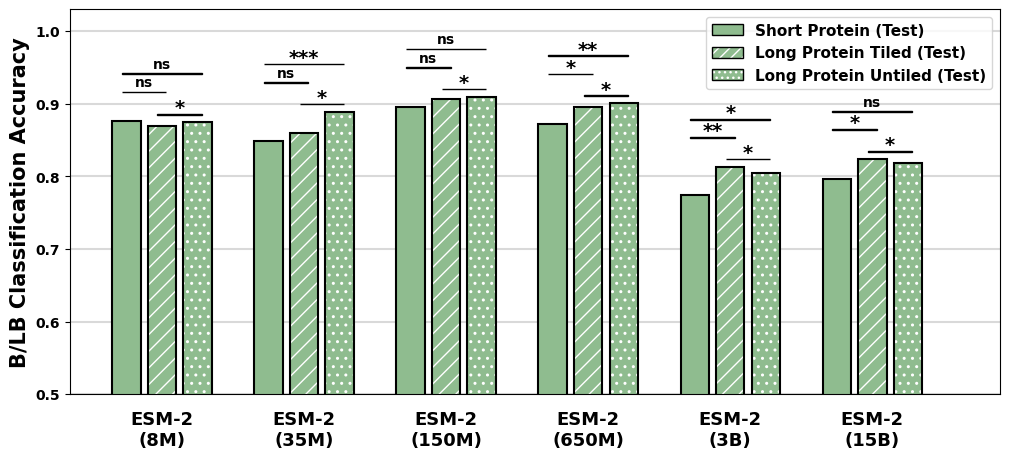

In [90]:
fig, ax = plt.subplots(figsize = (12,5))

data = []
labels = []
x = []

x_counter = 0
for m, results in rotary_v_tile_results_alt.items():
    labels.append(model_to_key[m])
    
    tn_short = results["short_test_cmat"][1][1]
    fp_short = results["short_test_cmat"][0][1] 
    
    tn_tiled = results["tn_tile"]
    fp_tiled = results["fp_tile"]
    
    tn_rotary = results["tn_rotary"]
    fp_rotary = results["fp_rotary"]
    
    data.append(tn_short / (tn_short+fp_short))
    data.append(tn_tiled / (tn_tiled + fp_tiled))
    data.append(tn_rotary / (tn_rotary + fp_rotary))
    data.append(0)
    
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    x.append(x_counter)
    x_counter += 1
    

ax.bar(x, data, color = "darkseagreen", edgecolor = "black", alpha = 1, linewidth = 1.5)
ax.set_yticks([0.5,0.6,0.7,0.8,0.9,1.0])
ax.set_ylim(bottom=0.5, top = 1.03)
ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold")


ax.set_xticks([])

hatch_list = ["", "//", "..", ""] * len(rotary_v_tile_results_alt)
patches = ax.patches
for patch, hatch in zip(patches, hatch_list):
    patch.set_hatch(hatch)
    patch._hatch_color = mcolors.to_rgba("white")

patch0 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 1, label='Short Protein (Test)')
patch0.set_edgecolor("black")

patch1 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 1, label='Long Protein Tiled (Test)')
patch1.set_hatch("///")
patch1.set_edgecolor("black")
patch1._hatch_color = mcolors.to_rgba("white")


patch2 = mpatches.Patch(color = "darkseagreen", edgecolor = "black", linewidth = 1, alpha = 1, label='Long Protein Untiled (Test)')
patch2.set_hatch("...")
patch2.set_edgecolor("black")
patch2._hatch_color = mcolors.to_rgba("white")

# plt.legend(handles=[patch0, patch1, patch2], bbox_to_anchor=(0.9,1.2,0.1,0.01))

plt.legend(handles=[patch0, patch1, patch2], loc = "upper right", prop={'weight': 'bold', 'size' : 11})


counter = 0
for i in np.arange(1, 4*len(labels), 4):
    ax.text(i, 0.43, labels[counter].replace(" ", "\n"), fontsize = 13, horizontalalignment = "center", fontweight = "bold")
    counter += 1

y_offset_1 = 0.01
for i, (m, results) in enumerate(rotary_v_tile_results_alt.items()):
    
    tn_short = results["short_test_cmat"][1][1]
    fp_short = results["short_test_cmat"][0][1] 
    
    tn_tiled = results["tn_tile"]
    fp_tiled = results["fp_tile"]
    
    tn_rotary = results["tn_rotary"]
    fp_rotary = results["fp_rotary"]
    
    
    y1 = data[i*4]
    y2 = data[(i*4) + 1]
    y3 = data[(i*4) + 2]
    
    
    point_0 = max(y2, y3) + y_offset_1 
    
    rect = mpatches.Rectangle(((i*4) + 1 - 0.125, point_0), 1.25, 0.001, color = "black")
    ax.add_patch(rect)
    
    chi_sq_0 = scipy.stats.chi2_contingency([
        [tp_tiled, fn_tiled],
        [tp_rotary, fn_rotary]
    ])[1]
    
    stars_0 = p_val_to_stars(chi_sq_0)
    
    
    fs = 10 if stars_0 == "ns" else 14
    star_offset = 0.008 if stars_0 == "ns" else 0.002
    ax.text((i*4) + 1.5, point_0 + star_offset, stars_0, fontsize = fs, fontweight = "bold", horizontalalignment = "center")
        
        
    point_1 = max(y1,y2) + y_offset_1 
    
    if point_1 < point_0:
        point_1 = point_0 + 0.03
        
    if abs(point_1 - point_0) < 0.03:
        point_1 += 0.03
        
    rect = mpatches.Rectangle(((i*4) - 0.125, point_1), 1.25, 0.001, color = "black")
    ax.add_patch(rect)

    
    chi_sq_1 = scipy.stats.chi2_contingency([
        [tn_short, fp_short],
        [tn_tiled, fp_tiled]
    ])[1]
    
    stars_1 = p_val_to_stars(chi_sq_1)
    
    
    fs = 10 if stars_1 == "ns" else 14
    star_offset = 0.008 if stars_1 == "ns" else 0.002
    ax.text((i*4) + 0.5, point_1 + star_offset, stars_1, fontsize = fs, fontweight = "bold", horizontalalignment = "center")
    
    

    
    point_2 = max(y1,y3) + y_offset_1 
    
    print(m, point_1, point_2)
    if abs(point_1 - point_2) < 0.03:
        print("in here", m)
        point_2 += 0.02
        
    if point_2 < point_1:
        point_2 = point_1 + 0.025
        
    rect = mpatches.Rectangle(((i*4) - 0.125, point_2), 2.25, 0.001, color = "black")
    ax.add_patch(rect)
    
    
    chi_sq_2 = scipy.stats.chi2_contingency([
        [tn_short, fp_short],
        [tn_rotary, fp_rotary]
    ])[1]
    
    stars_2 = p_val_to_stars(chi_sq_2)
    
    
    fs = 10 if stars_2 == "ns" else 14
    star_offset = 0.008 if stars_2 == "ns" else 0.002
    ax.text((i*4) + 1, point_2 + star_offset, stars_2, fontsize = fs, fontweight = "bold", horizontalalignment = "center")
    
#     ax.text((i*4) + 1, point_2 + 0.007, stars_2, horizontalalignment = "center")
    
    
ax.set_ylabel("B/LB Classification Accuracy", fontsize = 15, fontweight = "bold")



for y_tick in ax.get_yticks():
    ax.axhline(y = y_tick, zorder = 0, color = "black", alpha = 0.15)

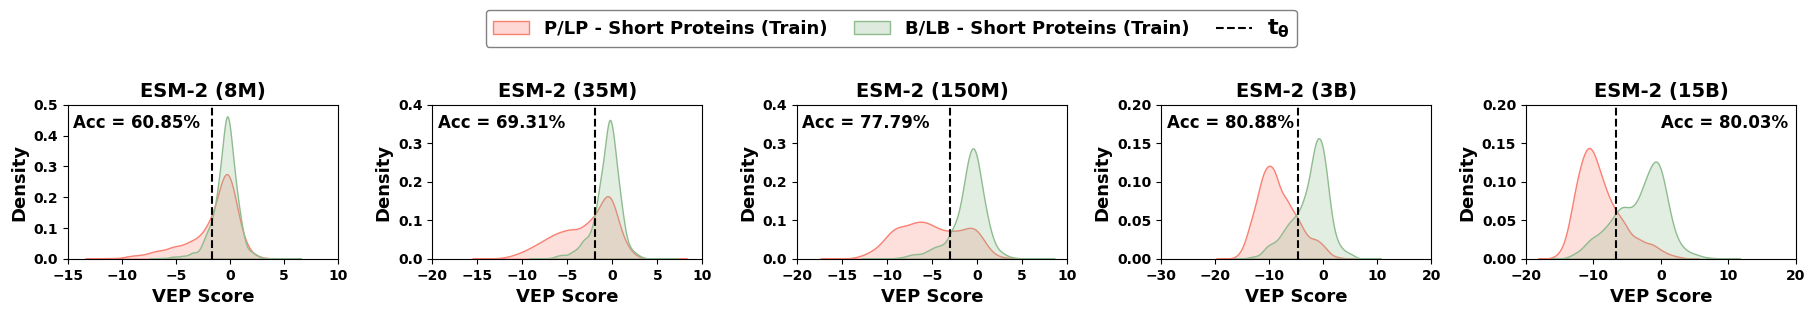

In [95]:
fig, axes = plt.subplots(1,6,figsize = (27,2))
fig.subplots_adjust( wspace = 0.35)
axes = axes.ravel()

ax_i = 0
for i , (k,v) in enumerate(rotary_v_tile_results_alt.items()):
    if k == "esm_2_650M":
        continue 
        
    blb_scores_to_plot = v["short_train_blb_scores"]
    plp_scores_to_plot = v["short_train_plp_scores"]
    ax  = axes[ax_i]
    
    ax_i += 1
    
    acc = v["short_protein_train_acc"]
    argmax_acc = v["short_protein_argmax_acc"]
    
    
    sns.kdeplot(plp_scores_to_plot, ax = ax, fill = True, color = "salmon", label = "P/LP - Short Protein (Train)")
    sns.kdeplot(blb_scores_to_plot, ax = ax, fill = True, color = "darkseagreen", label = "B/LB - Short Protein (Train)")

    ax.set_title(model_to_key[k], fontweight = "bold", fontsize = 14)
    ax.set_xlabel("VEP Score", fontsize = 13,  fontweight = "bold",)
    ax.set_ylabel("Density", fontsize = 13,  fontweight = "bold",)
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(ax.get_yticklabels(), fontweight = "bold", )
    
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), fontweight = "bold", )
    
    ax.axvline(x = argmax_acc, linestyle = "--", color = "black", alpha = 1,label = "$\phi_m$")

   

    acc_str = str(round(acc * 100, 2)) + "%"
    
    if k == "esm_2_15B":
        ax.text(0.5, 0.85, "Acc = " + acc_str, transform = ax.transAxes, fontweight = "bold", fontsize = 12)
#       
    else:
        ax.text(0.02, 0.85, "Acc = " + acc_str, transform = ax.transAxes, fontweight = "bold", fontsize = 12)


facecolor_plp = to_rgba('salmon', alpha=0.3)
edgecolor_plp = to_rgba('salmon', alpha=1)
facecolor_blb = to_rgba('darkseagreen', alpha=0.3)
edgecolor_blb = to_rgba('darkseagreen', alpha=1)

# Create custom legend handles
legend_elements = [
    Patch(facecolor=facecolor_plp, edgecolor=edgecolor_plp, label="P/LP - Short Proteins (Train)"),
    Patch(facecolor=facecolor_blb, edgecolor=edgecolor_blb, label="B/LB - Short Proteins (Train)"),
    Line2D([0], [0], color='black', linestyle='--', label=r'$\mathbf{t_{\theta}}$')
]


legend = fig.legend(
    handles=legend_elements,
    loc='upper center',
    ncol=3,
    framealpha=1,
    facecolor='white',
    edgecolor='gray',
    fontsize=18,
    prop = {"weight": "bold", "size" : 13},
    columnspacing=1.5,
    bbox_to_anchor=(0.43, 1.4)
)

# now customize just the Line2D text (the third item)
legend.get_texts()[2].set_fontsize(16)
legend.get_texts()[2].set_weight("bold")


fig.delaxes(axes[-1])

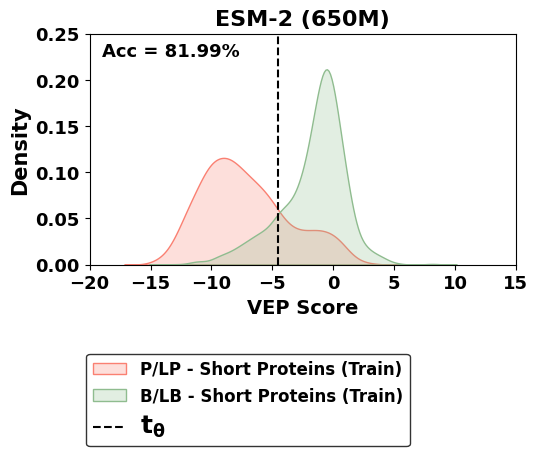

In [100]:

fig, ax = plt.subplots(figsize = (5.5,3))

k = "esm_2_650M"
v = rotary_v_tile_results_alt[k]

blb_scores_to_plot = v["short_train_blb_scores"]
plp_scores_to_plot = v["short_train_plp_scores"]

ax_i += 1

acc = v["short_protein_train_acc"]
argmax_acc = v["short_protein_argmax_acc"]


sns.kdeplot(plp_scores_to_plot, ax = ax, fill = True, color = "salmon", label = "P/LP - Short Proteins (Train)")
sns.kdeplot(blb_scores_to_plot, ax = ax, fill = True, color = "darkseagreen", label = "B/LB - Short Proteins (Train)")

ax.set_title(model_to_key[k], fontsize = 16, fontweight = "bold")
ax.set_xlabel("VEP Score", fontsize = 14, fontweight = "bold")
ax.set_ylabel("Density", fontsize = 15, fontweight = "bold")
ax.set_yticks(ax.get_yticks())
ax.set_xticks(ax.get_xticks())
ax.set_yticklabels(ax.get_yticklabels(), fontsize = 13, fontweight = "bold")
ax.set_xticklabels(ax.get_xticklabels(), fontsize = 13, fontweight = "bold")

ax.axvline(x = argmax_acc, linestyle = "--", color = "black", alpha = 1,label = r"$\mathbf{t_{\theta}}$")

legend = ax.legend(loc = "upper right", fontsize = 11, prop = {"weight": "bold", "size" : 12}, bbox_to_anchor = (-0.,0,0.77,-0.35), edgecolor = "black")

acc_str = str(round(acc * 100, 2)) + "%"

# now customize just the Line2D text (the third item)
legend.get_texts()[2].set_fontsize(18)
legend.get_texts()[2].set_weight("normal")


if k == "esm_2_15B":
    ax.text(0.65, 0.1, "Acc = " + acc_str, transform = ax.transAxes, fontweight = "bold")
else:
    ax.text(0.03, 0.9, "Acc = " + acc_str, transform = ax.transAxes, fontsize = 13, fontweight = "bold")
